# Part A: Naive Bayes Model & Metrics

In [ ]:
# ==========================================
# STEP 1: Load and Inspect Data
# ==========================================

import pandas as pd
from google.colab import drive
drive.mount('/content/drive')

# Load the dataset (Ensure the CSV file is in the same directory)
filename = 'enriched_data_CPU.csv'
#filename = '/content/drive/My Drive/synthetic_financial_data_NOISY.csv'
df = pd.read_csv(filename, sep='|') # Added sep='|' to handle the delimiter

print("✅ Data Loaded Successfully!")
print(f"Shape: {df.shape}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Data Loaded Successfully!
Shape: (950, 10)


In [ ]:
# ==========================================
# WIE3007 Group Project - Predictive Modelling
# Model: Naive Bayes (Hani's Part)
# ==========================================

# 1. Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning libraries from Scikit-Learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    f1_score,
    recall_score
)

In [ ]:
# ==========================================
# STEP 1: Load and Inspect Data
# ==========================================

from google.colab import drive
drive.mount('/content/drive')

# Load the dataset (Ensure the CSV file is in the same directory)

#filename = '/content/drive/My Drive/WIE3007_Project/final_clean_dataset.csv' # Corrected filename assignment
filename = 'enriched_data_CPU.csv'
df = pd.read_csv(filename, sep='|') # Added sep='|' for pipe-delimited file

print("✅ Data Loaded Successfully!")
print(f"Shape: {df.shape}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Data Loaded Successfully!
Shape: (950, 10)


In [ ]:
# ==========================================
# STEP 2: Data Preprocessing
# ==========================================

# 2.1 Drop columns that are not useful for prediction
# 'Customer_ID' is just an identifier.
# 'Loan_Officer_Note' is unstructured text (we assume 'Risk_Level' captures its sentiment).
df_clean = df.drop(columns=['Customer_ID', 'Loan_Officer_Note'])

# 2.2 Encoding Categorical Variables
# Naive Bayes (Gaussian) works best with numerical inputs.
# We must convert text categories into numbers.

# A. Original code attempted Ordinal Encoding for 'Risk_Level', but this column does not exist.
# risk_mapping = {'Low': 0, 'Medium': 1, 'High': 2}
# df_clean['Risk_Level'] = df_clean['Risk_Level'].map(risk_mapping)
# Based on available data, we will use 'Occupation_Bucket' for one-hot encoding.

# B. One-Hot Encoding for 'Occupation_Bucket' (Nominal data: no order)
# This converts 'Sales', 'Teacher', etc. into separate binary columns (0 or 1).
df_clean = pd.get_dummies(df_clean, columns=['Occupation_Bucket'], drop_first=True)

# C. Map 'Has_External_Asset' to numerical (1/0) if it's not already
# This addresses the 'could not convert string to float: 'No'' error.
if 'Has_External_Asset' in df_clean.columns and df_clean['Has_External_Asset'].dtype == 'object':
    asset_mapping = {'Yes': 1, 'No': 0}
    df_clean['Has_External_Asset'] = df_clean['Has_External_Asset'].map(asset_mapping)

# Ensure no NaNs in target variable before splitting
df_clean.dropna(subset=['Default_Status'], inplace=True)

# 2.3 Define Features (X) and Target (y)
# Target: 'Default_Status' (0 = Good, 1 = Default)
X = df_clean.drop(columns=['Default_Status'])
y = df_clean['Default_Status']

# 2.4 Split Data into Training and Testing Sets
# We use an 80-20 split (standard for this size of data)
# random_state=42 ensures we get the same split every time we run the code.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 2.5 Feature Scaling
# Gaussian Naive Bayes assumes data follows a normal distribution.
# Scaling helps features with large ranges (like Income) not dominate features with small ranges (like Age).
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ Data Preprocessing Complete.")

✅ Data Preprocessing Complete.


In [ ]:
# ==========================================
# STEP 3: Train Naive Bayes Model
# ==========================================

# Initialize the Gaussian Naive Bayes model
nb_model = GaussianNB()

# Before training, handle any potential NaNs in X_train_scaled
# Check for NaNs and remove corresponding rows
nan_rows = np.isnan(X_train_scaled).any(axis=1)
if nan_rows.any():
    X_train_cleaned = X_train_scaled[~nan_rows]
    y_train_cleaned = y_train[~nan_rows]
    print(f"⚠️ Warning: Removed {np.sum(nan_rows)} rows containing NaN values from training data.")
else:
    X_train_cleaned = X_train_scaled
    y_train_cleaned = y_train


# Train the model on the scaled and cleaned training data
nb_model.fit(X_train_cleaned, y_train_cleaned)

print("✅ Model Training Complete.")

✅ Model Training Complete.


In [ ]:
# ==========================================
# STEP 4: Evaluation & Metrics
# ==========================================

# Make predictions on the test set
y_pred = nb_model.predict(X_test_scaled)
y_prob = nb_model.predict_proba(X_test_scaled)[:, 1] # Probability for ROC-AUC

# Calculate core metrics
metric_accuracy = accuracy_score(y_test, y_pred)
metric_recall = recall_score(y_test, y_pred)
metric_f1 = f1_score(y_test, y_pred)
metric_auc = roc_auc_score(y_test, y_prob)

# Calculate feature importance for Gaussian Naive Bayes
# For GNB, a common way to infer importance is by looking at the absolute difference
# of feature means between classes. Features with larger differences tend to be more discriminative.
# We'll use the absolute difference between the means of features for class 0 (non-default) and class 1 (default).

# Get feature names from X_train (ensure they match the order in X_train_scaled)
feature_names = X_train.columns

# Get the means (theta_) for each feature for both classes (0 and 1)
# nb_model.theta_ has shape (n_classes, n_features)
means_class_0 = nb_model.theta_[0] # Means for class 0 (e.g., Not Default)
means_class_1 = nb_model.theta_[1] # Means for class 1 (e.g., Default)

# Calculate the absolute difference in means for each feature
feature_importance_diff = np.abs(means_class_1 - means_class_0)

# Create a Series for easier sorting and mapping with feature names
feature_importance_series = pd.Series(feature_importance_diff, index=feature_names)

# Sort features by importance (descending)
top_features = feature_importance_series.nlargest(5)

# Format the top features into a string for the prompt
top_features_str = "\n".join([f"- {name}: {value:.4f}" for name, value in top_features.items()])

# 4.1 Print Core Metrics
print("\n" + "="*40)
print("NAIVE BAYES MODEL PERFORMANCE")
print("="*40)
print(f"Accuracy:  {metric_accuracy:.4f}")
print(f"Recall:    {metric_recall:.4f} (Crucial for catching defaulters)")
print(f"F1-Score:  {metric_f1:.4f} (Balance of Precision/Recall)")
print(f"ROC-AUC:   {metric_auc:.4f}")
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


NAIVE BAYES MODEL PERFORMANCE
Accuracy:  0.7053
Recall:    0.3393 (Crucial for catching defaulters)
F1-Score:  0.4043 (Balance of Precision/Recall)
ROC-AUC:   0.6679

Classification Report:

              precision    recall  f1-score   support

           0       0.76      0.86      0.80       134
           1       0.50      0.34      0.40        56

    accuracy                           0.71       190
   macro avg       0.63      0.60      0.60       190
weighted avg       0.68      0.71      0.69       190



In [ ]:
# ==========================================
# STEP 5: Visualizations
# ==========================================

plt.figure(figsize=(12, 5))

# 5.1 Confusion Matrix Heatmap
plt.subplot(1, 2, 1)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.xticks([0.5, 1.5], ['Paid (0)', 'Default (1)'])
plt.yticks([0.5, 1.5], ['Paid (0)', 'Default (1)'])

# 5.2 ROC Curve
plt.subplot(1, 2, 2)
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc_score(y_test, y_prob):.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # Random guess line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")

plt.tight_layout()
plt.show()

print("✅ Visualizations Generated.")

# Part B: The LLM Analysis (The Insight)
Use LLMs to summarise findings, provide insights, and interpret feature importance.

In [ ]:
# ==========================================
# PART B: Automated LLM Analysis
# ==========================================
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig, pipeline

# Install bitsandbytes if not already installed or to ensure latest version
!pip install -U bitsandbytes

print("⏳ Loading LLM for Analysis...")

# 1. Setup Model (Same setup as your Data Gen lab)
model_name = "microsoft/Phi-3-mini-4k-instruct"

quant_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4"
)

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=quant_config,
    device_map="auto"
)

In [ ]:
# 2. Construct the Prompt Dynamically
# We inject the python variables from Part A directly into the string.
analysis_prompt = f"""[INST] You are a Data Science Expert. I have trained a Naive Bayes model to predict Loan Defaults.
Please analyze the performance metrics and feature importance listed below.

### MODEL PERFORMANCE:
- Accuracy: {metric_accuracy:.2%}
- Recall: {metric_recall:.2%} (Ability to catch actual defaulters)
- F1-Score: {metric_f1:.4f}
- ROC-AUC: {metric_auc:.4f}

### TOP 5 MOST IMPORTANT FEATURES:
{top_features_str}

### INSTRUCTIONS:
1. Summarize the model's performance. Is it good for risk management?
2. Interpret the Feature Importance. Why are these specific features predictive of loan default?
3. Provide one business recommendation based on these findings.
[/INST]"""

In [ ]:
# 3. Generate the Analysis
print("🤖 Generating Analysis from LLM...")

generator = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer,
    max_new_tokens=1024,
    do_sample=True,
    temperature=0.1,
    repetition_penalty=1.0 # <--- ADDED: Helps prevent getting stuck/repeating
)

output = generator(analysis_prompt)
generated_text = output[0]['generated_text']

In [ ]:
# 4. Display Result
print("\n" + "="*50)
print("📝 LLM AUTOMATED FINDINGS & INSIGHTS")
print("="*50)
# Clean up output to show only the response
print(generated_text.split("[/INST]")[-1].strip())

# GRADIENT BOOSTING

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Dropped 0 rows with missing target values.
Final Shape: (950, 10)
🤖 Training Gradient Boosting Model...
✅ Training Complete!

--- Gradient Boosting Performance ---
Accuracy:  73.16%
ROC AUC:   0.7102

Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.93      0.83       134
           1       0.61      0.25      0.35        56

    accuracy                           0.73       190
   macro avg       0.68      0.59      0.59       190
weighted avg       0.71      0.73      0.69       190



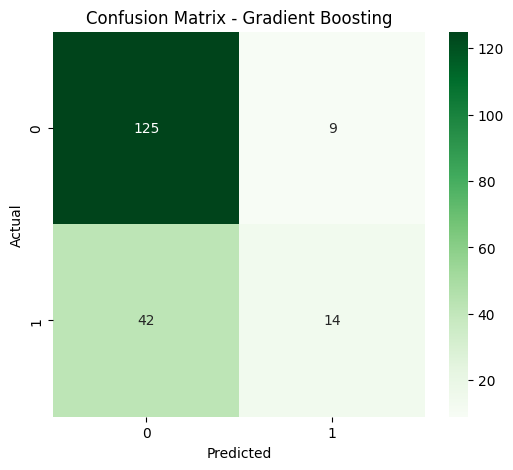

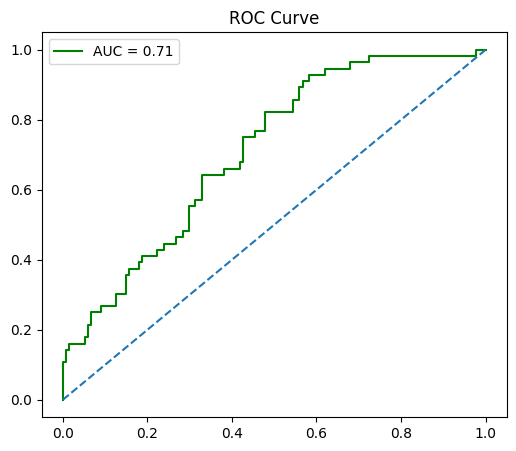

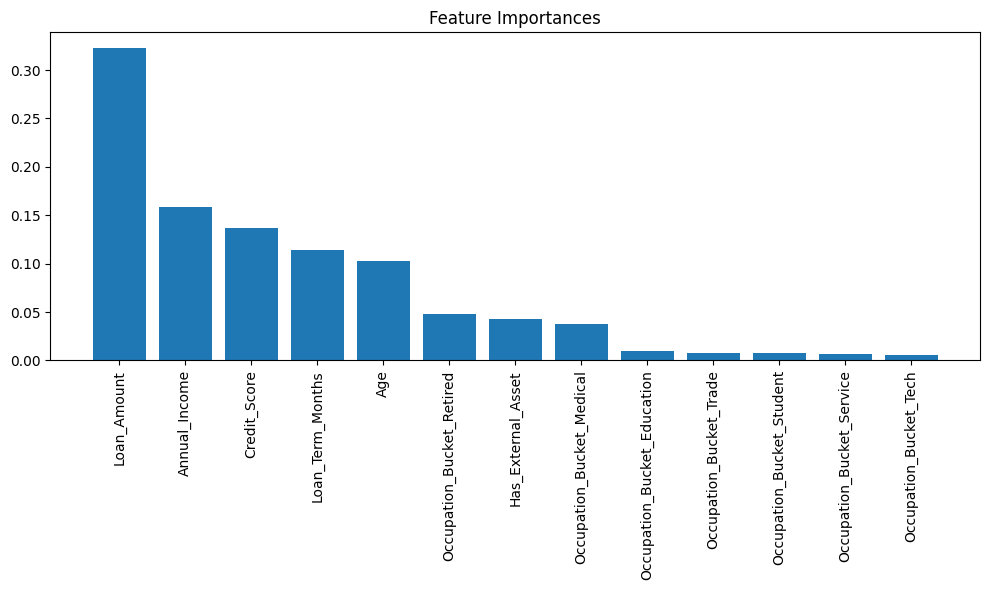

In [ ]:
# ==========================================
# WIE3007 Group Project - Predictive Modelling
# Model: Gradient Boosting (Ensemble Method)
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, f1_score, recall_score
)

# ==========================================
# STEP 1: Load and Clean Data
# ==========================================
from google.colab import drive
drive.mount('/content/drive')

filename = 'enriched_data_CPU.csv'
df = pd.read_csv(filename, sep='|')

# Clean Column Names (Strip whitespace)
df.columns = df.columns.str.strip()

# --- 🚨 SAFETY FIX: REMOVE NULL TARGETS 🚨 ---
# This fixes the "Input y contains NaN" error
initial_count = len(df)
df = df.dropna(subset=['Default_Status'])
print(f"✅ Dropped {initial_count - len(df)} rows with missing target values.")

# Ensure Default_Status is an integer (0 or 1)
df['Default_Status'] = df['Default_Status'].astype(int)

print(f"Final Shape: {df.shape}")

# ==========================================
# STEP 2: Preprocessing
# ==========================================

# 2.1 Drop ID and Text columns (We used them for Feature Engineering already)
# Check if columns exist before dropping to avoid errors
cols_to_drop = ['Customer_ID', 'Loan_Officer_Note']
df_clean = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

# 2.2 Feature Engineering (One-Hot Encoding)
# Convert 'Occupation_Bucket' to numbers
df_clean = pd.get_dummies(df_clean, columns=['Occupation_Bucket'], drop_first=True)

# Add mapping for 'Has_External_Asset' to numerical (1/0) if it's not already
if 'Has_External_Asset' in df_clean.columns and df_clean['Has_External_Asset'].dtype == 'object':
    asset_mapping = {'Yes': 1, 'No': 0}
    df_clean['Has_External_Asset'] = df_clean['Has_External_Asset'].map(asset_mapping)

# 2.3 Split X (Features) and y (Target)
X = df_clean.drop(columns=['Default_Status'])
y = df_clean['Default_Status']

# 2.4 Train/Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 2.5 Scale Data (StandardScaler)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ==========================================
# STEP 3: Train Gradient Boosting
# ==========================================

print("🤖 Training Gradient Boosting Model...")
gb_model = GradientBoostingClassifier(
    n_estimators=100,  # Number of trees
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)
gb_model.fit(X_train_scaled, y_train)
print("✅ Training Complete!")

# ==========================================
# STEP 4: Evaluation
# ==========================================

# Predictions
y_pred = gb_model.predict(X_test_scaled)
y_pred_proba = gb_model.predict_proba(X_test_scaled)[:, 1]

# Metrics
print("\n--- Gradient Boosting Performance ---")
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.2%}")
print(f"ROC AUC:   {roc_auc_score(y_test, y_pred_proba):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix - Gradient Boosting')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='green', label=f'AUC = {roc_auc_score(y_test, y_pred_proba):.2f}')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.title('ROC Curve')
plt.legend()
plt.show()

# Feature Importance
feature_names = X.columns
importances = gb_model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.title("Feature Importances")
plt.bar(range(X.shape[1]), importances[indices], align="center")
plt.xticks(range(X.shape[1]), feature_names[indices], rotation=90)
plt.tight_layout()
plt.show()

Using SMOTE

This is the most common problem in fraud and default prediction. The reason your Precision and Recall for Default=1 are low is Class Imbalance.

The Problem: The "Needle in a Haystack" Effect
Imagine you have 100 loans:

90 are Good (0)

10 are Defaults (1)

Your model is smart. It realizes: "If I just guess 'Good' for everyone, I will get 90% Accuracy without doing any work!"

Result: It correctly identifies the 90 Good loans, but it misses the 10 Bad loans.

Symptom: High Accuracy (90%), but 0% Recall for Defaults.

In your specific dataset, "Good" loans drastically outnumber "Bad" loans, so the Gradient Boosting model is being lazy and prioritizing the majority class.

The Solution: SMOTE (Synthetic Minority Over-sampling Technique)
To fix this, we need to force the model to pay attention to the Defaults. We use SMOTE, which creates "synthetic" (fake but realistic) examples of Default loans until the classes are balanced (50/50).

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Original Training Counts: [561 351]
Balanced Training Counts: [561 561]
🤖 Training Gradient Boosting on Balanced Data...

--- Performance with SMOTE ---
Accuracy:  69.87%
ROC AUC:   0.7150

Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.74      0.75       141
           1       0.60      0.62      0.61        88

    accuracy                           0.70       229
   macro avg       0.68      0.68      0.68       229
weighted avg       0.70      0.70      0.70       229



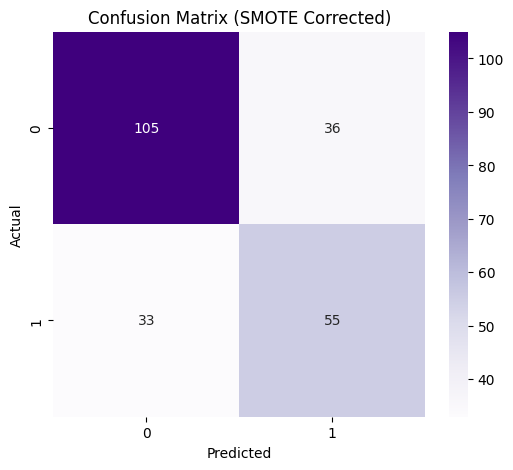

In [ ]:
# ==========================================
# WIE3007 Group Project - Predictive Modelling
# Model: Gradient Boosting with SMOTE (Fixing Imbalance)
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve
)
# Import SMOTE to fix the imbalance
from imblearn.over_sampling import SMOTE

# 1. Load Data
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/My Drive/WIE3007_Project/final_clean_dataset.csv', sep='|')
df.columns = df.columns.str.strip()
df = df.dropna(subset=['Default_Status']) # Drop NaNs

# 2. Preprocessing
df_clean = df.drop(columns=['Customer_ID', 'Loan_Officer_Note'])
df_clean = pd.get_dummies(df_clean, columns=['Occupation_Bucket'], drop_first=True)
X = df_clean.drop(columns=['Default_Status'])
y = df_clean['Default_Status'].astype(int)

# 3. Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 4. Scale Data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- 🚨 THE FIX: APPLY SMOTE 🚨 ---
print(f"Original Training Counts: {np.bincount(y_train)}")
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)
print(f"Balanced Training Counts: {np.bincount(y_train_balanced)}")
# -----------------------------------

# 5. Train Model on BALANCED Data
print("🤖 Training Gradient Boosting on Balanced Data...")
gb_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
gb_model.fit(X_train_balanced, y_train_balanced)

# 6. Evaluation
y_pred = gb_model.predict(X_test_scaled)
y_pred_proba = gb_model.predict_proba(X_test_scaled)[:, 1]

print("\n--- Performance with SMOTE ---")
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.2%}")
print(f"ROC AUC:   {roc_auc_score(y_test, y_pred_proba):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Purples')
plt.title('Confusion Matrix (SMOTE Corrected)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()